# Analyse du Risque de Crédit — NYSE & NASDAQ Companies (1999–2018)

## Analyse Comparative Entre Les Modèles De Rating De Risque De Crédit
**Projet de Fin d'Année — Bank of Africa, Business Center Agadir**

---

### Dataset Description
This notebook analyzes the **American Bankruptcy Prediction** dataset of NYSE & NASDAQ listed companies.
The dataset has been **cleaned** to fix **target leakage (look-ahead bias)**: the `failed` label is
restricted to a company's final year only, resetting prior years to `alive`.

- **Source**: [Kaggle](https://www.kaggle.com/datasets/utkarshx27/american-companies-bankruptcy-prediction-dataset)
- **Records**: 78,682 company-year observations
- **Companies**: Multiple years of financial data per company (panel data)
- **Features**: 18 financial variables + 5 derived ratios (cleaned version)
- **Target**: `status_corrected` (alive/failed)
- **Period**: 1999–2018

### Key Methodological Decisions
1. **Target Leakage Fix**: Failed label restricted to final year only
2. **Out-of-Time (OOT) Sampling**: Train 1999–2014, Test 2015–2018 (chronological split)
3. **Derived Ratios**: ratio_liquidite, ratio_endettement, roa, fdr_sur_actifs, re_sur_actifs

### Feature Descriptions
| Feature | Description |
|---|---|
| X1 | Current Assets |
| X2 | Cost of Goods Sold |
| X3 | Depreciation and Amortization |
| X4 | EBITDA |
| X5 | Inventory |
| X6 | Net Income |
| X7 | Total Receivables |
| X8 | **Market Value (Market Capitalization)** |
| X9 | Net Sales |
| X10 | Total Assets |
| X11 | Total Long-term Debt |
| X12 | EBIT |
| X13 | Gross Profit |
| X14 | Total Current Liabilities |
| X15 | Retained Earnings |
| X16 | Total Revenue |
| X17 | Total Liabilities |
| X18 | Total Operating Expenses |

### Models Applied (ALL 4 Paradigms)
1. **Classical Econometric**: Logistic Regression, Probit, LDA, **Altman Z-Score (fully computable)**
2. **Machine Learning**: XGBoost, LightGBM, Random Forest, SVM, kNN, CART, MLP
3. **Structural & Market-Based**: **Merton model (partially applicable — has market value X8)**
4. **Dynamic Stochastic**: **Markov Chains + Cox PH (both fully applicable — panel data)**

## Setup

In [2]:
import subprocess, sys
for pkg in ['lightgbm', 'shap', 'lifelines']:
    try: __import__(pkg)
    except ImportError: subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg])

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import *
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.kernel_approximation import Nystroem
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline
import xgboost as xgb
import lightgbm as lgb
import statsmodels.api as sm
import shap
from scipy import stats
from lifelines import CoxPHFitter
sns.set_style('whitegrid'); plt.rcParams['figure.figsize']=(12,6); plt.rcParams['font.size']=12
print('Libraries loaded.')

Libraries loaded.


---
## Phase 1 — Modeling Scope Framing

| Dimension | Description |
|---|---|
| **Scoring Type** | Corporate bankruptcy prediction (listed companies) |
| **Population** | NYSE & NASDAQ listed companies (1999–2018) |
| **Time Horizon** | 20-year panel data, annual observations |
| **Data Structure** | Longitudinal panel: company × year |
| **Target** | Binary: failed vs. alive (corrected for look-ahead bias) |
| **Sampling** | **Out-of-Time (OOT)**: Train 1999–2014, Test 2015–2018 |
| **Special** | Has **market value** (X8) → enables Merton model and Altman Z-Score |

---
## Phase 2 — Data Preparation and Cleansing

In [4]:
# Load the CLEANED dataset (target leakage already fixed by user)
df = pd.read_csv('american_bankruptcy_cleaned.csv')
print(f'Dataset shape: {df.shape[0]:,} company-year observations, {df.shape[1]} columns')
print(f'Years: {df["year"].min()} to {df["year"].max()}')
print(f'Unique companies: {df["company_name"].nunique()}')
df.head()

Dataset shape: 78,682 company-year observations, 26 columns
Years: 1999 to 2018
Unique companies: 8971


,company_name,year,X1,X2,X3,X4,X5,X6,X7,X8,...,X15,X16,X17,X18,status_corrected,ratio_liquidite,ratio_endettement,roa,fdr_sur_actifs,re_sur_actifs
0,C_1,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,372.7519,...,201.026,1024.333,401.483,935.302,alive,3.120983,0.541814,0.047454,0.468896,0.271291
1,C_1,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,377.1180,...,204.065,874.255,361.642,809.888,alive,3.874697,0.515267,0.026403,0.513588,0.290751
2,C_1,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,364.5928,...,139.603,638.721,399.964,611.514,alive,2.902063,0.563172,-0.082989,0.402974,0.196569
3,C_1,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,143.3295,...,124.106,606.337,391.633,575.592,alive,1.947253,0.570377,-0.018074,0.280849,0.180749
4,C_1,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,308.9071,...,131.884,651.958,407.608,604.467,alive,3.292707,0.574669,0.004940,0.424286,0.185938


In [5]:
# Target distribution
target_col = 'status_corrected'
print(f'Target distribution:\n{df[target_col].value_counts()}')
print(f'Failure rate: {(df[target_col]=="failed").mean():.4%}')

# Encode target: alive=0, failed=1
df['target'] = (df[target_col] == 'failed').astype(int)
target_col = 'target'

Target distribution:
status_corrected
alive     78073
failed      609
Name: count, dtype: int64
Failure rate: 0.7740%


In [6]:
# Identify feature columns
raw_features = [f'X{i}' for i in range(1, 19)]
derived_features = ['ratio_liquidite', 'ratio_endettement', 'roa', 'fdr_sur_actifs', 're_sur_actifs']
feature_cols = [c for c in raw_features + derived_features if c in df.columns]
print(f'Features: {len(feature_cols)} ({len(raw_features)} raw + {len([c for c in derived_features if c in df.columns])} derived)')

# Handle missing/infinite values
for c in feature_cols:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
df[feature_cols] = df[feature_cols].fillna(df[feature_cols].median())

print(f'Missing after cleaning: {df[feature_cols].isnull().sum().sum()}')

Features: 23 (18 raw + 5 derived)
Missing after cleaning: 0


---
## Phase 3 — Out-of-Time (OOT) Sampling

Instead of random train/test split, we use **chronological splitting** to simulate
real-world credit scoring: **predicting the future using the past**.

- **Training set**: 1999–2014
- **Test set**: 2015–2018

In [7]:
# OOT Split
df_train = df[df['year'] <= 2014].copy()
df_test = df[df['year'] >= 2015].copy()

X_train = df_train[feature_cols]
y_train = df_train[target_col]
X_test = df_test[feature_cols]
y_test = df_test[target_col]

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(f'Training: {X_train.shape[0]:,} obs ({df_train["year"].min()}-{df_train["year"].max()}), failure rate: {y_train.mean():.4%}')
print(f'Test:     {X_test.shape[0]:,} obs ({df_test["year"].min()}-{df_test["year"].max()}), failure rate: {y_test.mean():.4%}')
print(f'\nThis OOT split prevents the model from training on a company\'s future data points.')

Training: 66,400 obs (1999-2014), failure rate: 0.7380%
Test:     12,282 obs (2015-2018), failure rate: 0.9689%

This OOT split prevents the model from training on a company's future data points.


---
## Phase 4 — Variable Analysis

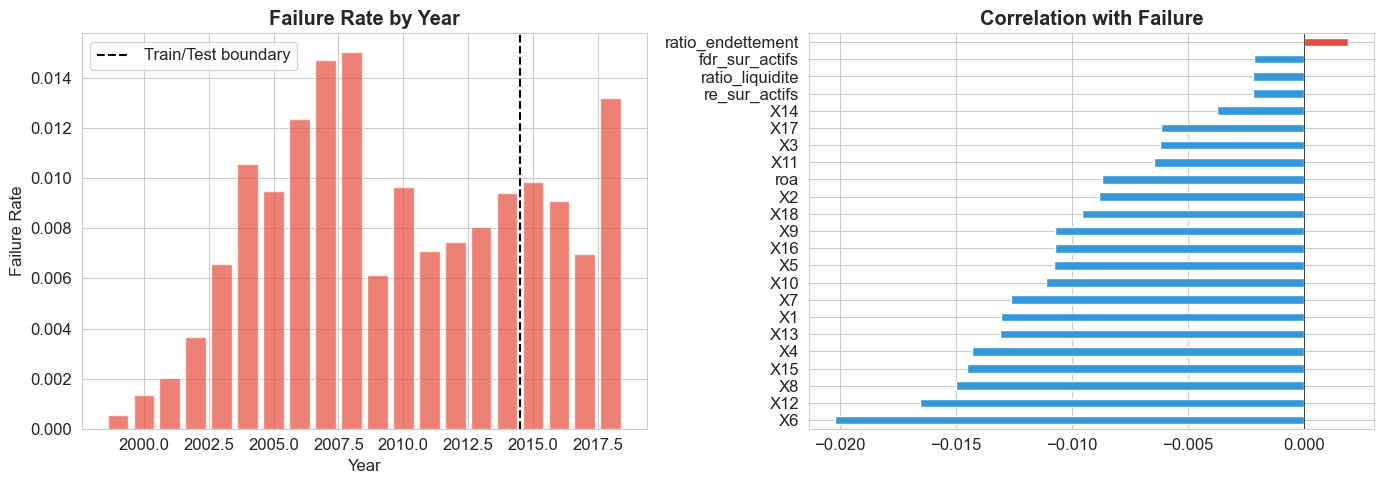

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Failure over time
yearly = df.groupby('year')[target_col].agg(['count', 'sum'])
yearly['rate'] = yearly['sum'] / yearly['count']
axes[0].bar(yearly.index, yearly['rate'], color='#e74c3c', alpha=0.7)
axes[0].set_xlabel('Year'); axes[0].set_ylabel('Failure Rate')
axes[0].set_title('Failure Rate by Year', fontweight='bold')
axes[0].axvline(x=2014.5, color='black', ls='--', label='Train/Test boundary')
axes[0].legend()

# Correlation with target
corr_t = df[feature_cols + [target_col]].corr()[target_col].drop(target_col).sort_values()
colors = ['#e74c3c' if v>0 else '#3498db' for v in corr_t]
corr_t.plot(kind='barh', ax=axes[1], color=colors)
axes[1].set_title('Correlation with Failure', fontweight='bold')
axes[1].axvline(0, color='k', lw=0.5)
plt.tight_layout(); plt.show()

---
## Phase 5 — Pre-processing
### Information Value

In [9]:
def calc_iv(df, feat, tgt, bins=10):
    d = df[[feat, tgt]].dropna().copy()
    try:
        if d[feat].nunique() > bins: d['b'] = pd.qcut(d[feat], q=bins, duplicates='drop')
        else: d['b'] = d[feat]
        g = d.groupby('b', observed=True)[tgt].agg(['count','sum'])
        g.columns=['total','ev']; g['nev']=g['total']-g['ev']
        te,tne=max(g['ev'].sum(),1),max(g['nev'].sum(),1)
        g['er']=g['ev'].replace(0,0.5)/te; g['ner']=g['nev'].replace(0,0.5)/tne
        g['woe']=np.log(g['ner']/g['er']); g['iv']=(g['ner']-g['er'])*g['woe']
        return g['iv'].sum()
    except: return 0

iv = pd.DataFrame({'Feature': feature_cols, 'IV': [calc_iv(pd.concat([X_train,y_train],axis=1), c, target_col) for c in feature_cols]})
iv = iv.sort_values('IV', ascending=False)
iv['Strength'] = iv['IV'].apply(lambda x: 'Very Strong' if x>=0.5 else 'Strong' if x>=0.3 else 'Medium' if x>=0.1 else 'Weak' if x>=0.02 else 'Useless')
print(iv.to_string(index=False))

          Feature       IV    Strength
ratio_endettement 1.093551 Very Strong
               X6 0.984580 Very Strong
              roa 0.861429 Very Strong
               X8 0.761979 Very Strong
  ratio_liquidite 0.753516 Very Strong
   fdr_sur_actifs 0.681248 Very Strong
              X15 0.669022 Very Strong
              X12 0.606853 Very Strong
    re_sur_actifs 0.593531 Very Strong
               X4 0.354698      Strong
               X1 0.142311      Medium
               X7 0.133820      Medium
              X13 0.128269      Medium
              X10 0.114932      Medium
               X9 0.082665        Weak
              X16 0.082665        Weak
              X14 0.080300        Weak
              X18 0.078290        Weak
               X5 0.076863        Weak
              X17 0.072738        Weak
               X2 0.065541        Weak
              X11 0.039019        Weak
               X3 0.029744        Weak


---
## Phase 6 — Modeling

In [10]:
results = {}; colors_p = plt.cm.Set2(np.linspace(0,1,15))
def eval_model(name, mdl, Xtr, Xte, ytr, yte, par='ML'):
    mdl.fit(Xtr, ytr); yp = mdl.predict(Xte)
    if hasattr(mdl,'predict_proba'): ypr = mdl.predict_proba(Xte)[:,1]
    elif hasattr(mdl,'decision_function'): ypr = 1/(1+np.exp(-mdl.decision_function(Xte)))
    else: ypr = yp.astype(float)
    a=accuracy_score(yte,yp); au=roc_auc_score(yte,ypr); g=2*au-1
    f=f1_score(yte,yp,zero_division=0); p=precision_score(yte,yp,zero_division=0); r=recall_score(yte,yp)
    b=brier_score_loss(yte,ypr); fp,tp,_=roc_curve(yte,ypr); ks=max(tp-fp)
    results[name]={'paradigm':par,'model':mdl,'y_pred':yp,'y_prob':ypr,'accuracy':a,'auc':au,'gini':g,'ks':ks,'f1':f,'precision':p,'recall':r,'brier':b}
    print(f'  {name}: Acc={a:.4f} AUC={au:.4f} Gini={g:.4f} KS={ks:.4f} F1={f:.4f} Brier={b:.4f}')
    return mdl

##### We solve the SVM probability issue by using a Nystroem kernel approximation followed by a LinearSVC, and then calibrating the output probabilities with CalibratedClassifierCV. This allows us to obtain probability estimates without using the `probability=True` parameter of SVC, which can be computationally expensive.
# 1. Define the base approximation pipeline
nystroem_pipeline = make_pipeline(
    Nystroem(gamma=0.2, random_state=1, n_components=500),
    LinearSVC(class_weight='balanced', dual=False, max_iter=10000)
)

# 2. Wrap the pipeline to compute probabilities (replaces probability=True from SVC)
probabilistic_svm = CalibratedClassifierCV(estimator=nystroem_pipeline, cv=5)


### 6.1 Paradigm 1 — Classical Econometric

In [11]:
print('=== Paradigm 1: Econometric ===')
eval_model('Logistic Regression', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42), X_train_scaled, X_test_scaled, y_train, y_test, 'Econometric')

=== Paradigm 1: Econometric ===
  Logistic Regression: Acc=0.6805 AUC=0.8469 Gini=0.6939 KS=0.5375 F1=0.0462 Brier=0.1704


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [12]:
Xc=sm.add_constant(X_train_scaled); Xtc=sm.add_constant(X_test_scaled)
pr=sm.Probit(y_train,Xc).fit(disp=0,maxiter=100)
ypp=pr.predict(Xtc); ypd=(ypp>=0.5).astype(int)
a=accuracy_score(y_test,ypd); au=roc_auc_score(y_test,ypp); g=2*au-1
f=f1_score(y_test,ypd,zero_division=0); fp,tp,_=roc_curve(y_test,ypp); ks=max(tp-fp)
b=brier_score_loss(y_test,ypp)
results['Probit']={'paradigm':'Econometric','model':pr,'y_pred':ypd,'y_prob':ypp,'accuracy':a,'auc':au,'gini':g,'ks':ks,'f1':f,'precision':precision_score(y_test,ypd,zero_division=0),'recall':recall_score(y_test,ypd),'brier':b}
print(f'  Probit: Acc={a:.4f} AUC={au:.4f} Gini={g:.4f} KS={ks:.4f} F1={f:.4f} Brier={b:.4f}')

  Probit: Acc=0.9905 AUC=0.8270 Gini=0.6540 KS=0.5093 F1=0.0488 Brier=0.0091


c:\Users\Elem\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [13]:
eval_model('LDA', LinearDiscriminantAnalysis(), X_train_scaled, X_test_scaled, y_train, y_test, 'Econometric')

  LDA: Acc=0.9893 AUC=0.7978 Gini=0.5955 KS=0.4929 F1=0.0294 Brier=0.0105


,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


#### Altman Z-Score (Fully Computable)

  Altman Z-Score: Acc=0.5979 AUC=0.7934 Gini=0.5869 KS=0.5606 F1=0.0408 Brier=0.3133
  NOTE: FULLY computed using raw financial items. X4 uses actual market capitalization (X8).


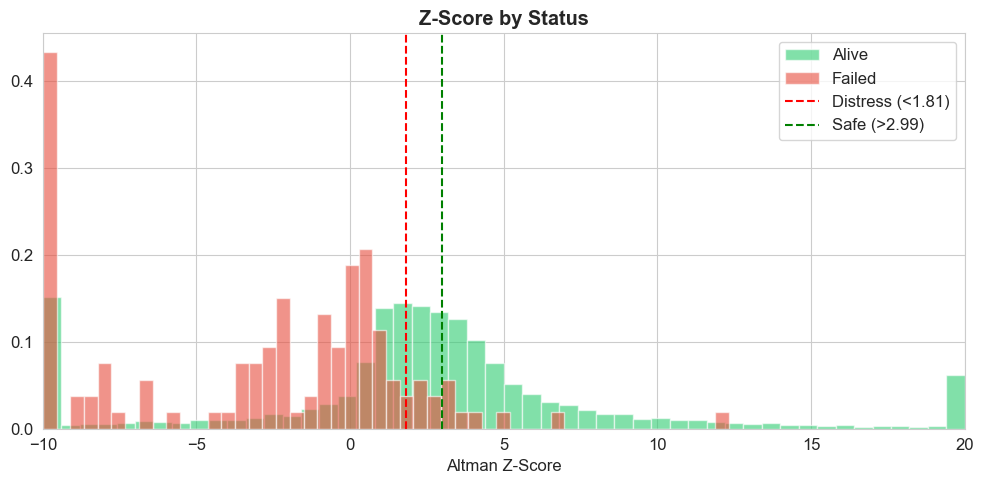

In [14]:
# Altman Z-Score: Z = 1.2*X1 + 1.4*X2 + 3.3*X3 + 0.6*X4 + 1.0*X5
# Mapping to NYSE/NASDAQ variables:
#   Altman X1 = Working Capital/TA = (X1_current_assets - X14_current_liab) / X10_total_assets
#   Altman X2 = Retained Earnings/TA = X15_retained_earnings / X10_total_assets
#   Altman X3 = EBIT/TA = X12_ebit / X10_total_assets
#   Altman X4 = Market Value Equity/BV Total Debt = X8_market_value / X17_total_liabilities
#   Altman X5 = Sales/TA = X9_net_sales / X10_total_assets

z1 = (X_test['X1'] - X_test['X14']) / X_test['X10'].replace(0, np.nan)  # WC/TA
z2 = X_test['X15'] / X_test['X10'].replace(0, np.nan)                    # RE/TA
z3 = X_test['X12'] / X_test['X10'].replace(0, np.nan)                    # EBIT/TA
z4 = X_test['X8'] / X_test['X17'].replace(0, np.nan)                     # MV Equity/BV Debt
z5 = X_test['X9'] / X_test['X10'].replace(0, np.nan)                     # Sales/TA

z_score = 1.2 * z1.fillna(0) + 1.4 * z2.fillna(0) + 3.3 * z3.fillna(0) + 0.6 * z4.fillna(0) + 1.0 * z5.fillna(0)

z_pred = (z_score < 1.81).astype(int)
z_prob = 1 / (1 + np.exp(z_score.clip(-20, 20) - 1.81))

a = accuracy_score(y_test, z_pred); au = roc_auc_score(y_test, z_prob)
g = 2*au-1; f = f1_score(y_test, z_pred, zero_division=0); b = brier_score_loss(y_test, z_prob)
fpr_z, tpr_z, _ = roc_curve(y_test, z_prob); ks = max(tpr_z - fpr_z)
results['Altman Z-Score'] = {'paradigm':'Econometric','model':None,'y_pred':z_pred,'y_prob':z_prob,
    'accuracy':a,'auc':au,'gini':g,'ks':ks,'f1':f,'precision':precision_score(y_test,z_pred,zero_division=0),
    'recall':recall_score(y_test,z_pred,zero_division=0),'brier':b}
print(f'  Altman Z-Score: Acc={a:.4f} AUC={au:.4f} Gini={g:.4f} KS={ks:.4f} F1={f:.4f} Brier={b:.4f}')
print('  NOTE: FULLY computed using raw financial items. X4 uses actual market capitalization (X8).')

fig, ax = plt.subplots(figsize=(10, 5))
zs = z_score.clip(-10, 20)
ax.hist(zs[y_test==0], bins=50, alpha=0.6, label='Alive', color='#2ecc71', density=True)
ax.hist(zs[y_test==1], bins=50, alpha=0.6, label='Failed', color='#e74c3c', density=True)
ax.axvline(1.81, color='red', ls='--', label='Distress (<1.81)')
ax.axvline(2.99, color='green', ls='--', label='Safe (>2.99)')
ax.set_xlabel('Altman Z-Score'); ax.set_title('Z-Score by Status', fontweight='bold')
ax.legend(); ax.set_xlim([-10, 20]); plt.tight_layout(); plt.show()

### 6.2 Paradigm 2 — Machine Learning

In [15]:
print('=== Paradigm 2: ML ===')
eval_model('XGBoost', xgb.XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, scale_pos_weight=(y_train==0).sum()/max((y_train==1).sum(),1), random_state=42, eval_metric='logloss', verbosity=0), X_train, X_test, y_train, y_test)
eval_model('LightGBM', lgb.LGBMClassifier(n_estimators=200, max_depth=6, is_unbalance=True, random_state=42, verbose=-1), X_train, X_test, y_train, y_test)
eval_model('Random Forest', RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1), X_train, X_test, y_train, y_test)
eval_model('SVM (Nystroem RBF)', probabilistic_svm, X_train_scaled, X_test_scaled, y_train, y_test)
eval_model('kNN', KNeighborsClassifier(n_neighbors=7, n_jobs=-1), X_train_scaled, X_test_scaled, y_train, y_test)
eval_model('CART', DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=42), X_train, X_test, y_train, y_test)
eval_model('MLP', MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=42, early_stopping=True), X_train_scaled, X_test_scaled, y_train, y_test)

=== Paradigm 2: ML ===
  XGBoost: Acc=0.9716 AUC=0.8576 Gini=0.7153 KS=0.5833 F1=0.1550 Brier=0.0215
  LightGBM: Acc=0.9608 AUC=0.7024 Gini=0.4047 KS=0.4610 F1=0.1454 Brier=0.0327
  Random Forest: Acc=0.9468 AUC=0.8990 Gini=0.7981 KS=0.6681 F1=0.1596 Brier=0.0396
  SVM (Nystroem RBF): Acc=0.9905 AUC=0.8165 Gini=0.6329 KS=0.5257 F1=0.0331 Brier=0.0090
  kNN: Acc=0.9904 AUC=0.6301 Gini=0.2602 KS=0.2575 F1=0.0167 Brier=0.0096
  CART: Acc=0.8381 AUC=0.7948 Gini=0.5897 KS=0.5975 F1=0.0805 Brier=0.1120
  MLP: Acc=0.9903 AUC=0.6705 Gini=0.3410 KS=0.3188 F1=0.0000 Brier=0.0096


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",500
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


### 6.3 Paradigm 3 — Structural & Market-Based Models

#### Merton Option Pricing Model (Partial Implementation)

This dataset uniquely has **Market Value (X8)** — the market capitalization of listed companies.
Combined with Total Liabilities (X17), we can compute the **Distance to Default (DD)**.

**However**, a full Merton implementation requires:
- Equity volatility (σ_E) from daily stock returns → we approximate using year-to-year changes in X8
- Risk-free rate (r) → we use a constant 3% proxy
- Debt maturity (T) → we use T=1 (one-year horizon)

**Caveat**: This is a **simplified approximation**. True Merton requires daily stock price data
and iterative solving of the Black-Scholes equations for asset value and volatility.

  Merton (Approx.): Acc=0.6332 AUC=0.8738 Gini=0.7476 KS=0.6211 F1=0.0453 Brier=0.2851
  CAVEAT: Uses year-to-year market cap changes as volatility proxy.
  True Merton requires daily stock returns and iterative Black-Scholes solving.


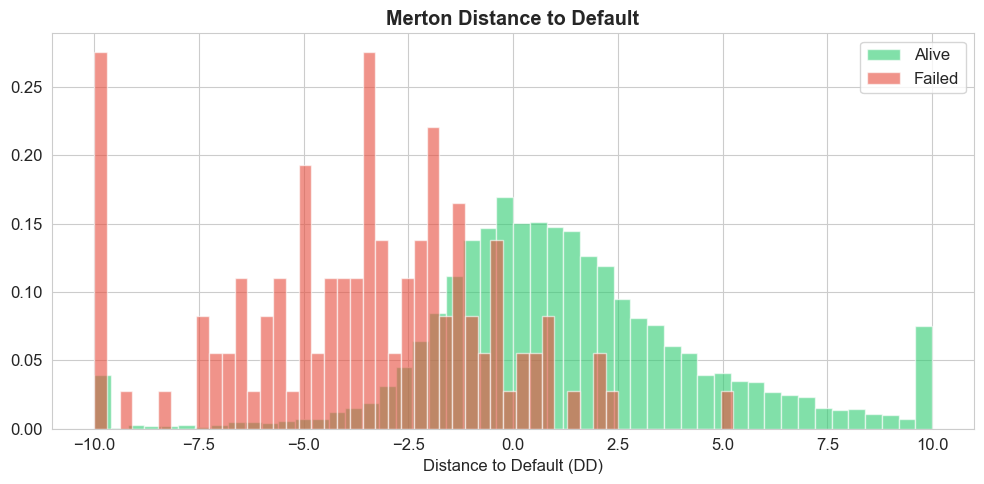

In [17]:
# Simplified Merton Distance to Default (DD)
# DD = (ln(V/D) + (r - 0.5*sigma^2)*T) / (sigma * sqrt(T))
# Where V = Market Value, D = Total Liabilities, sigma = equity volatility

# Estimate equity volatility from year-to-year changes in market value
df_sorted = df.sort_values(['company_name', 'year'])
df_sorted['X8_pct_change'] = df_sorted.groupby('company_name')['X8'].pct_change()

# Compute volatility per company (std of log returns)
vol_per_company = df_sorted.groupby('company_name')['X8_pct_change'].std().reset_index()
vol_per_company.columns = ['company_name', 'sigma_E']
vol_per_company['sigma_E'] = vol_per_company['sigma_E'].fillna(vol_per_company['sigma_E'].median())

# Merge volatility back
df_test_merton = df_test.merge(vol_per_company, on='company_name', how='left')
df_test_merton['sigma_E'] = df_test_merton['sigma_E'].fillna(vol_per_company['sigma_E'].median())

# Compute DD
V = df_test_merton['X8'].replace(0, np.nan).clip(lower=1)  # Market Value
D = df_test_merton['X17'].replace(0, np.nan).clip(lower=1)  # Total Liabilities
sigma = df_test_merton['sigma_E'].clip(lower=0.01)
r = 0.03  # risk-free rate proxy
T = 1     # 1-year horizon

DD = (np.log(V / D) + (r - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
DD = DD.fillna(0).clip(-10, 10)

# Convert DD to PD using normal CDF: PD = N(-DD)
from scipy.stats import norm
merton_prob = norm.cdf(-DD)
merton_pred = (merton_prob >= 0.5).astype(int)

# Evaluate
a = accuracy_score(y_test, merton_pred); au = roc_auc_score(y_test, merton_prob)
g = 2*au-1; f = f1_score(y_test, merton_pred, zero_division=0)
b = brier_score_loss(y_test, merton_prob)
fpr_m, tpr_m, _ = roc_curve(y_test, merton_prob); ks = max(tpr_m - fpr_m)

results['Merton (Approx.)'] = {'paradigm':'Structural','model':None,'y_pred':merton_pred,'y_prob':merton_prob,
    'accuracy':a,'auc':au,'gini':g,'ks':ks,'f1':f,'precision':precision_score(y_test,merton_pred,zero_division=0),
    'recall':recall_score(y_test,merton_pred,zero_division=0),'brier':b}
print(f'  Merton (Approx.): Acc={a:.4f} AUC={au:.4f} Gini={g:.4f} KS={ks:.4f} F1={f:.4f} Brier={b:.4f}')
print('  CAVEAT: Uses year-to-year market cap changes as volatility proxy.')
print('  True Merton requires daily stock returns and iterative Black-Scholes solving.')

alive_mask = y_test.to_numpy() == 0
failed_mask = y_test.to_numpy() == 1

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(DD[alive_mask], bins=50, alpha=0.6, label='Alive', color='#2ecc71', density=True)
ax.hist(DD[failed_mask], bins=50, alpha=0.6, label='Failed', color='#e74c3c', density=True)
ax.set_xlabel('Distance to Default (DD)'); ax.set_title('Merton Distance to Default', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

> **Moody's KMV Framework**: Cannot be implemented as it requires Moody's **proprietary**
> default database to map Distance to Default → Expected Default Frequency.
> The mapping function is not publicly available.

### 6.4 Paradigm 4 — Dynamic Stochastic Models

#### Markov Chains — Credit Migration Matrix

=== Markov Transition Matrix (1-year) ===
next_status     Alive    Failed
target                         
Alive        0.991407  0.008593
Failed       0.000000  0.000000

P(Alive→Failed) = 0.008593
P(Failed→Alive) = 0.000000 (recovery rate)


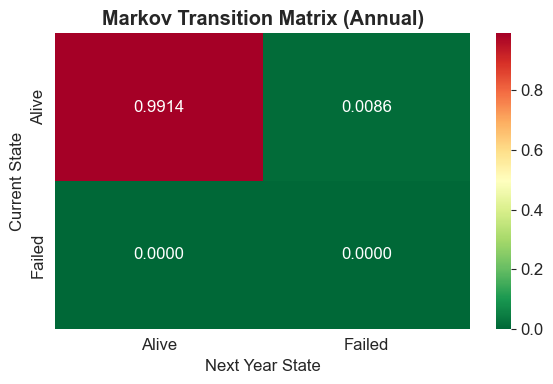

In [19]:
# Markov Chain: Year-to-year transition matrix (alive→alive, alive→failed)
# Since this is panel data, we can compute transition probabilities

df_sorted = df.sort_values(['company_name', 'year'])
df_sorted['next_status'] = df_sorted.groupby('company_name')[target_col].shift(-1)

# Only keep rows where we have both current and next year status
transitions = df_sorted.dropna(subset=['next_status'])
transitions['next_status'] = transitions['next_status'].astype(int)

categories = ['Alive', 'Failed']

# Compute transition matrix
trans_matrix = pd.crosstab(
    transitions[target_col].map({0: 'Alive', 1: 'Failed'}),
    transitions['next_status'].map({0: 'Alive', 1: 'Failed'}),
    normalize='index'
).reindex(index=categories, columns=categories, fill_value=0)

print('=== Markov Transition Matrix (1-year) ===')
print(trans_matrix.round(6))
print(f'\nP(Alive→Failed) = {trans_matrix.loc["Alive", "Failed"]:.6f}')
print(f'P(Failed→Alive) = {trans_matrix.loc["Failed", "Alive"]:.6f} (recovery rate)')

# Visualize
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(trans_matrix, annot=True, fmt='.4f', cmap='RdYlGn_r', ax=ax)
ax.set_title('Markov Transition Matrix (Annual)', fontweight='bold')
ax.set_ylabel('Current State'); ax.set_xlabel('Next Year State')
plt.tight_layout(); plt.show()

In [20]:
# Multi-step transition: predict n-year ahead default probability
tm = trans_matrix.values  # 2x2 matrix
print('Multi-year default probabilities (starting from Alive state):')
for n in [1, 2, 3, 5, 10]:
    tm_n = np.linalg.matrix_power(tm, n)
    print(f'  {n}-year PD = {tm_n[0, 1]:.6f}')

Multi-year default probabilities (starting from Alive state):
  1-year PD = 0.008593
  2-year PD = 0.008519
  3-year PD = 0.008446
  5-year PD = 0.008301
  10-year PD = 0.007951


#### Cox Proportional Hazards — Survival Analysis

In [21]:
# Cox PH: Model time-to-failure for each company
# Construct survival data: first observation year → failure year (or last observed year)

company_stats = df.groupby('company_name').agg(
    first_year=('year', 'min'),
    last_year=('year', 'max'),
    failed=(target_col, 'max')  # 1 if ever failed
).reset_index()

company_stats['duration'] = company_stats['last_year'] - company_stats['first_year'] + 1
company_stats['duration'] = company_stats['duration'].clip(lower=1)

# Get the last observation's features for each company
last_obs = df.sort_values('year').groupby('company_name').last().reset_index()
surv_df = company_stats.merge(last_obs[['company_name'] + feature_cols[:5]], on='company_name')

# Clean
surv_df = surv_df.replace([np.inf, -np.inf], np.nan).dropna()
for c in feature_cols[:5]:
    q1, q99 = surv_df[c].quantile(0.01), surv_df[c].quantile(0.99)
    surv_df[c] = surv_df[c].clip(q1, q99)

# Fit Cox PH
cox_cols = feature_cols[:5] + ['duration', 'failed']
cph = CoxPHFitter(penalizer=0.1)
cph.fit(surv_df[cox_cols], duration_col='duration', event_col='failed')
cph.print_summary()
print(f'\nConcordance Index: {cph.concordance_index_:.4f}')

<lifelines.CoxPHFitter: fitted with 8971 total observations, 8362 right-censored observations>
             duration col = 'duration'
                event col = 'failed'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 8971
number of events observed = 609
   partial log-likelihood = -5024.34
         time fit was run = 2026-06-26 08:51:57 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
X1        -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
X2        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
X3        -0.00      1.00      0.00           -0.00            0.00                1.00                1.00
X4        -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
X5        -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00

           cmp to     z      p  -log2(p)
covariate                               
X1           0.00 -3.09 <0.005      8.95
X2           0.00 -0.98   0.33      1.61
X3           0.00 -0.08   0.93      0.10
X4           0.00 -3.56 <0.005     11.38
X5           0.00 -2.38   0.02      5.84
---
Concordance = 0.64
Partial AIC = 10058.68
log-likelihood ratio test = 63.33 on 5 df
-log2(p) of ll-ratio test = 38.55


Concordance Index: 0.6387


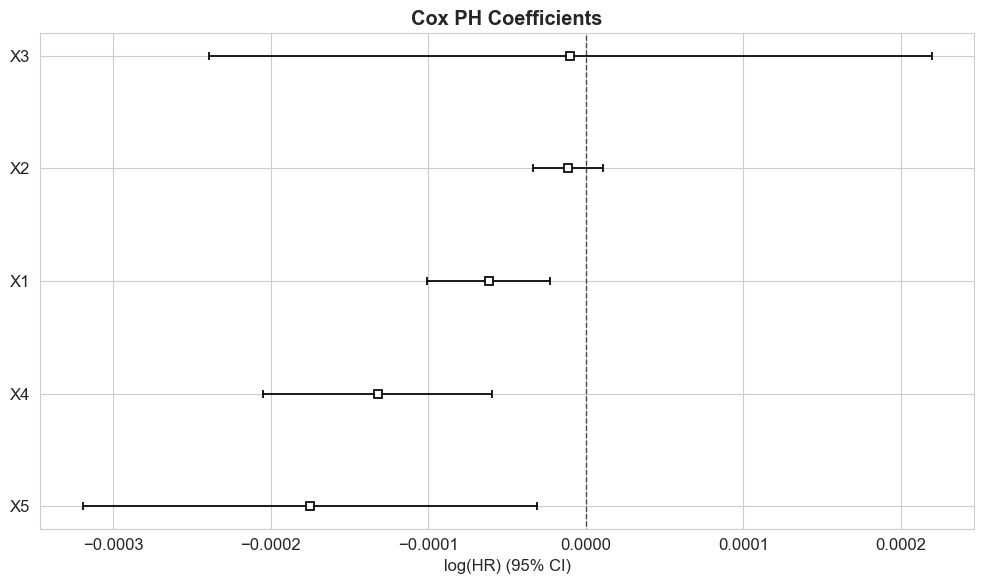

In [22]:
# Survival curve
fig, ax = plt.subplots(figsize=(10, 6))
cph.plot(ax=ax)
ax.set_title('Cox PH Coefficients', fontweight='bold')
plt.tight_layout(); plt.show()

---
## Phase 7 — Evaluation on Test Set (OOT: 2015–2018)

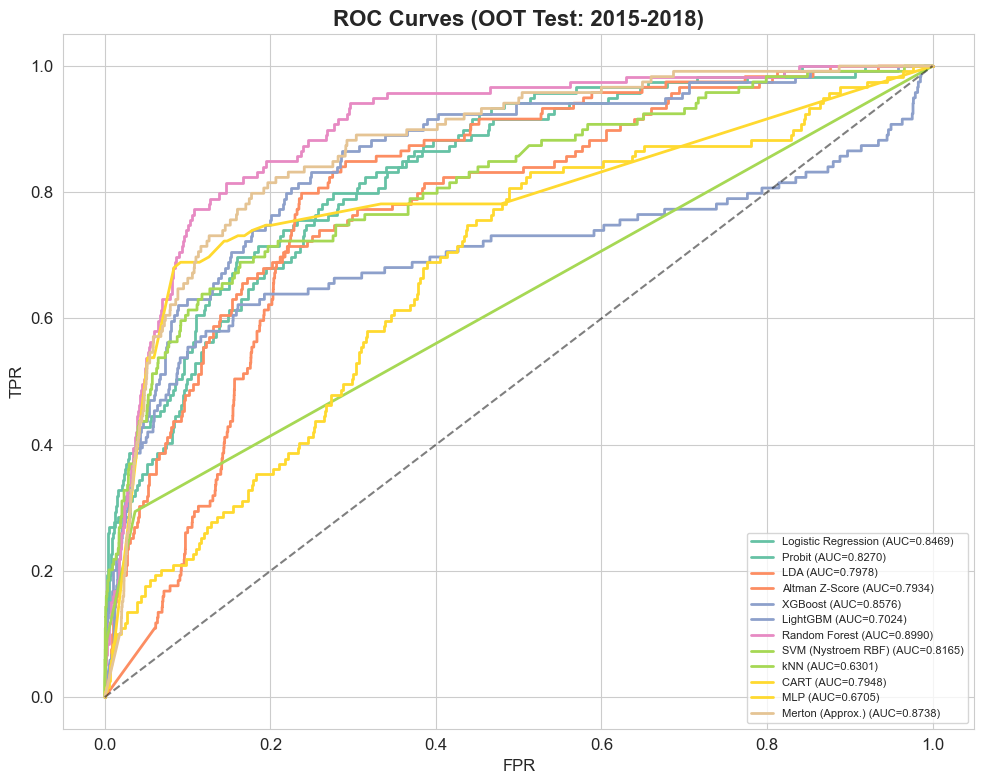

In [23]:
fig, ax = plt.subplots(figsize=(10, 8))
for i, (n, r) in enumerate(results.items()):
    fp, tp, _ = roc_curve(y_test, r['y_prob'])
    ax.plot(fp, tp, label=f"{n} (AUC={r['auc']:.4f})", color=colors_p[i%len(colors_p)], linewidth=2)
ax.plot([0,1],[0,1],'k--',alpha=0.5); ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves (OOT Test: 2015-2018)', fontsize=16, fontweight='bold')
ax.legend(loc='lower right', fontsize=8); plt.tight_layout(); plt.show()

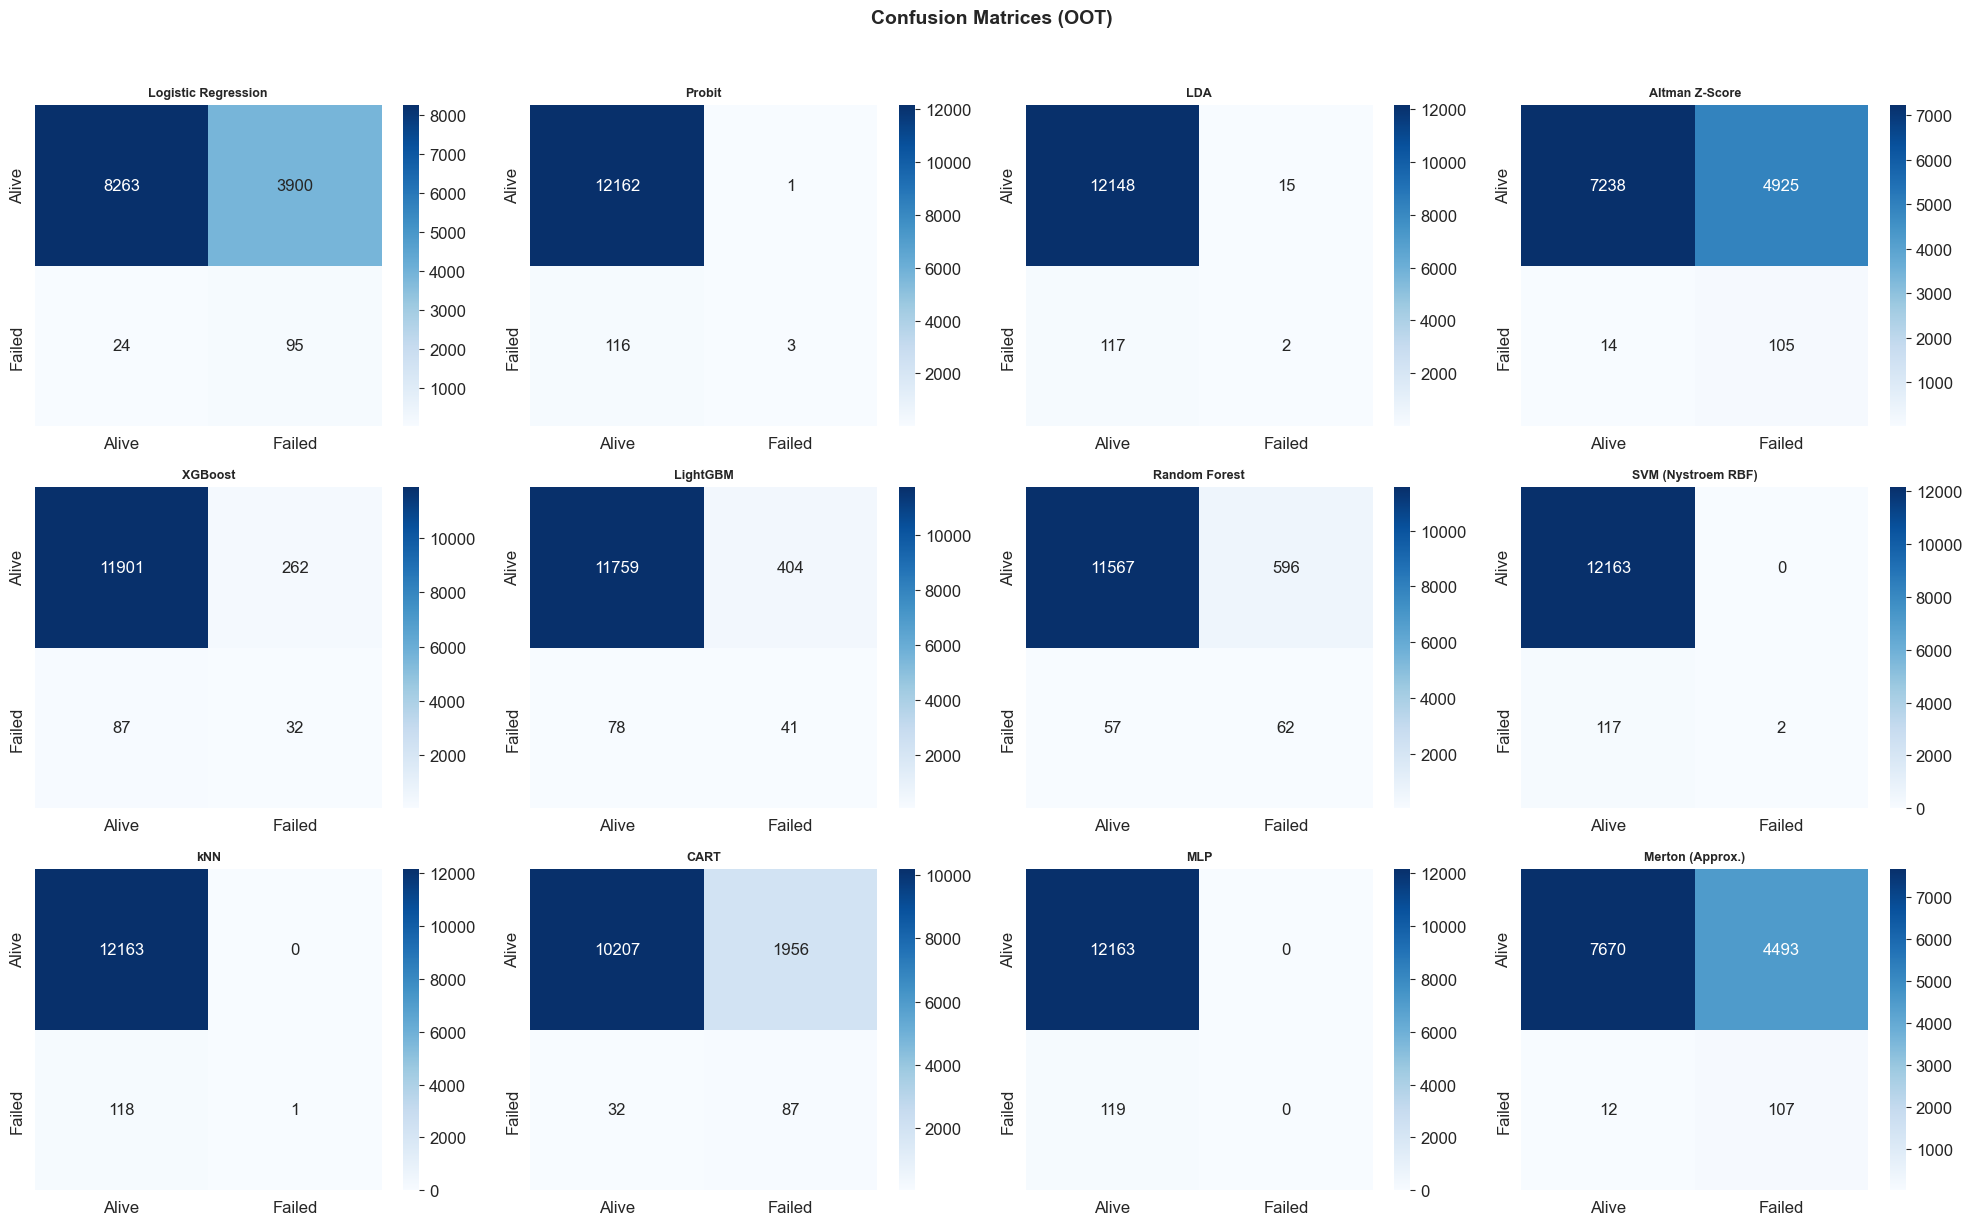

In [24]:
n=len(results); nc=4; nr=(n+nc-1)//nc
fig,axes=plt.subplots(nr,nc,figsize=(5*nc,4*nr)); axes=axes.flatten()
for i,(n,r) in enumerate(results.items()):
    cm=confusion_matrix(y_test,r['y_pred'])
    sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=axes[i],xticklabels=['Alive','Failed'],yticklabels=['Alive','Failed'])
    axes[i].set_title(n,fontweight='bold',fontsize=9)
for j in range(i+1,len(axes)): axes[j].set_visible(False)
plt.suptitle('Confusion Matrices (OOT)',fontsize=14,fontweight='bold',y=1.02); plt.tight_layout(); plt.show()

In [25]:
for n,r in results.items():
    print(f'\n=== {n} ({r["paradigm"]}) ==='); print(classification_report(y_test,r['y_pred'],target_names=['Alive','Failed']))


=== Logistic Regression (Econometric) ===
              precision    recall  f1-score   support

       Alive       1.00      0.68      0.81     12163
      Failed       0.02      0.80      0.05       119

    accuracy                           0.68     12282
   macro avg       0.51      0.74      0.43     12282
weighted avg       0.99      0.68      0.80     12282


=== Probit (Econometric) ===
              precision    recall  f1-score   support

       Alive       0.99      1.00      1.00     12163
      Failed       0.75      0.03      0.05       119

    accuracy                           0.99     12282
   macro avg       0.87      0.51      0.52     12282
weighted avg       0.99      0.99      0.99     12282


=== LDA (Econometric) ===
              precision    recall  f1-score   support

       Alive       0.99      1.00      0.99     12163
      Failed       0.12      0.02      0.03       119

    accuracy                           0.99     12282
   macro avg       0.55     

---
## Phase 8 — Model Calibration

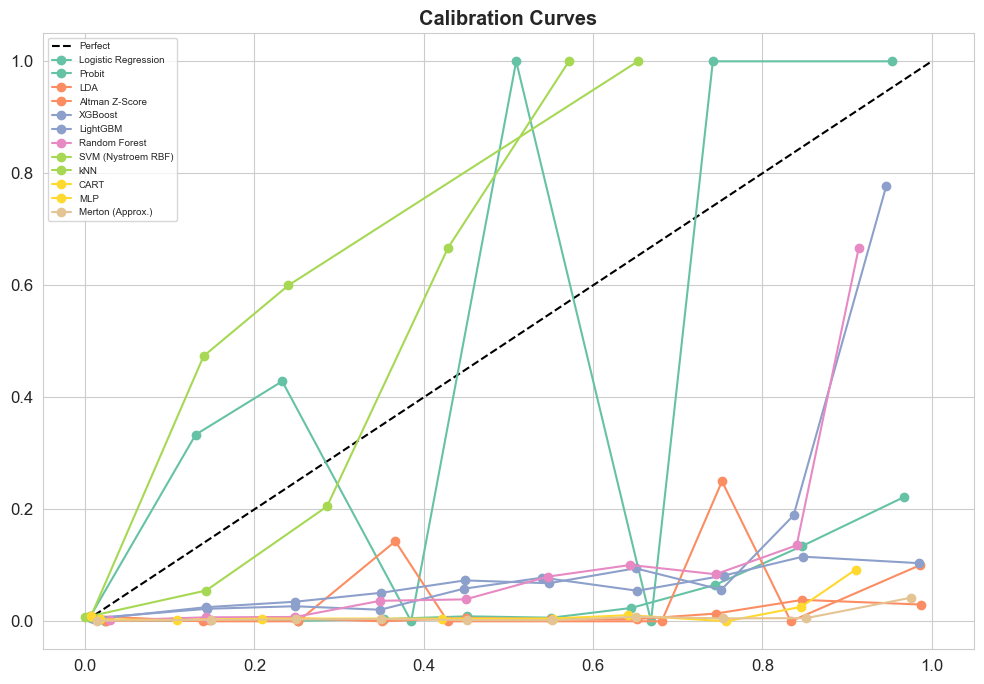

In [26]:
fig,ax=plt.subplots(figsize=(10,7)); ax.plot([0,1],[0,1],'k--',label='Perfect')
for i,(n,r) in enumerate(results.items()):
    try: pt,pp=calibration_curve(y_test,r['y_prob'],n_bins=10); ax.plot(pp,pt,marker='o',label=n,color=colors_p[i%len(colors_p)])
    except: pass
ax.set_title('Calibration Curves',fontweight='bold'); ax.legend(fontsize=7); plt.tight_layout(); plt.show()

In [27]:
print('Brier Score:')
for n,r in sorted(results.items(),key=lambda x:x[1]['brier']): print(f"  {n:30s} Brier={r['brier']:.6f}")

Brier Score:
  SVM (Nystroem RBF)             Brier=0.008955
  Probit                         Brier=0.009144
  MLP                            Brier=0.009560
  kNN                            Brier=0.009583
  LDA                            Brier=0.010462
  XGBoost                        Brier=0.021507
  LightGBM                       Brier=0.032748
  Random Forest                  Brier=0.039565
  CART                           Brier=0.111982
  Logistic Regression            Brier=0.170399
  Merton (Approx.)               Brier=0.285146
  Altman Z-Score                 Brier=0.313294


---
## Phase 9 — Post-Model Calibration

In [28]:
bml=max([k for k,v in results.items() if v['paradigm']=='ML'],key=lambda k:results[k]['auc'])
print(f'Post-calibration for: {bml}')
us=bml in ['SVM','kNN','MLP']; Xtr=X_train_scaled if us else X_train; Xte=X_test_scaled if us else X_test
for m,l in [('sigmoid','Platt'),('isotonic','Isotonic')]:
    try:
        base=results[bml]['model'].__class__(**results[bml]['model'].get_params())
        c=CalibratedClassifierCV(base,method=m,cv=3); c.fit(Xtr,y_train)
        yp=c.predict_proba(Xte)[:,1]; print(f'  {l}: Brier={brier_score_loss(y_test,yp):.6f} (orig: {results[bml]["brier"]:.6f})')
    except Exception as e: print(f'  {l}: Failed — {e}')

Post-calibration for: Random Forest
  Platt: Brier=0.009136 (orig: 0.039565)
  Isotonic: Brier=0.009121 (orig: 0.039565)


---
## Phase 10 — Interpretability (SHAP)

SHAP: Random Forest


<Figure size 1000x800 with 0 Axes>

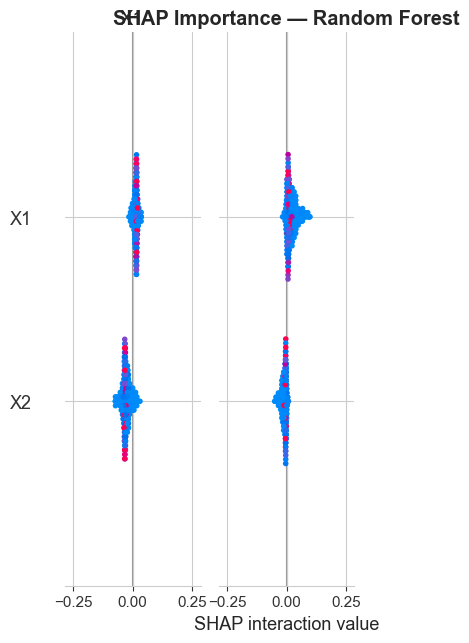

In [29]:
tm={k:v for k,v in results.items() if k in ['XGBoost','LightGBM','Random Forest','CART']}
bt=max(tm.keys(),key=lambda k:tm[k]['auc']); print(f'SHAP: {bt}')
exp=shap.TreeExplainer(results[bt]['model'])
Xs=X_test.sample(min(500,len(X_test)),random_state=42)
sv=exp.shap_values(Xs)
if isinstance(sv,list): sv=sv[1]
plt.figure(figsize=(10,8)); shap.summary_plot(sv,Xs,plot_type='bar',show=False)
plt.title(f'SHAP Importance — {bt}',fontweight='bold'); plt.tight_layout(); plt.show()

<Figure size 1000x800 with 0 Axes>

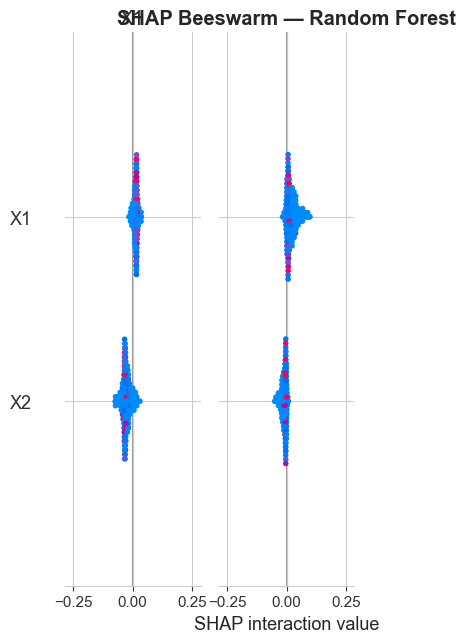

In [30]:
plt.figure(figsize=(10,8)); shap.summary_plot(sv,Xs,show=False)
plt.title(f'SHAP Beeswarm — {bt}',fontweight='bold'); plt.tight_layout(); plt.show()

---
## Phase 11 — Final Comparative Summary

In [31]:
comp=pd.DataFrame({k:[results[m][k] for m in results] for k in ['accuracy','auc','gini','ks','f1','precision','recall','brier']})
comp.insert(0,'Model',list(results.keys())); comp.insert(1,'Paradigm',[results[m]['paradigm'] for m in results])
comp=comp.sort_values('auc',ascending=False).reset_index(drop=True); comp.index+=1; comp.index.name='Rank'
print('=== FINAL COMPARISON — NYSE/NASDAQ (OOT: Train 1999-2014, Test 2015-2018) ==='); print(comp.to_string())

=== FINAL COMPARISON — NYSE/NASDAQ (OOT: Train 1999-2014, Test 2015-2018) ===
                    Model     Paradigm  accuracy       auc      gini        ks        f1  precision    recall     brier
Rank                                                                                                                   
1           Random Forest           ML  0.946833  0.899036  0.798072  0.668123  0.159588   0.094225  0.521008  0.039565
2        Merton (Approx.)   Structural  0.633203  0.873785  0.747570  0.621060  0.045349   0.023261  0.899160  0.285146
3                 XGBoost           ML  0.971584  0.857643  0.715286  0.583310  0.154964   0.108844  0.268908  0.021507
4     Logistic Regression  Econometric  0.680508  0.846928  0.693856  0.537486  0.046184   0.023780  0.798319  0.170399
5                  Probit  Econometric  0.990474  0.826986  0.653972  0.509298  0.048780   0.750000  0.025210  0.009144
6      SVM (Nystroem RBF)           ML  0.990474  0.816464  0.632929  0.525711  0.

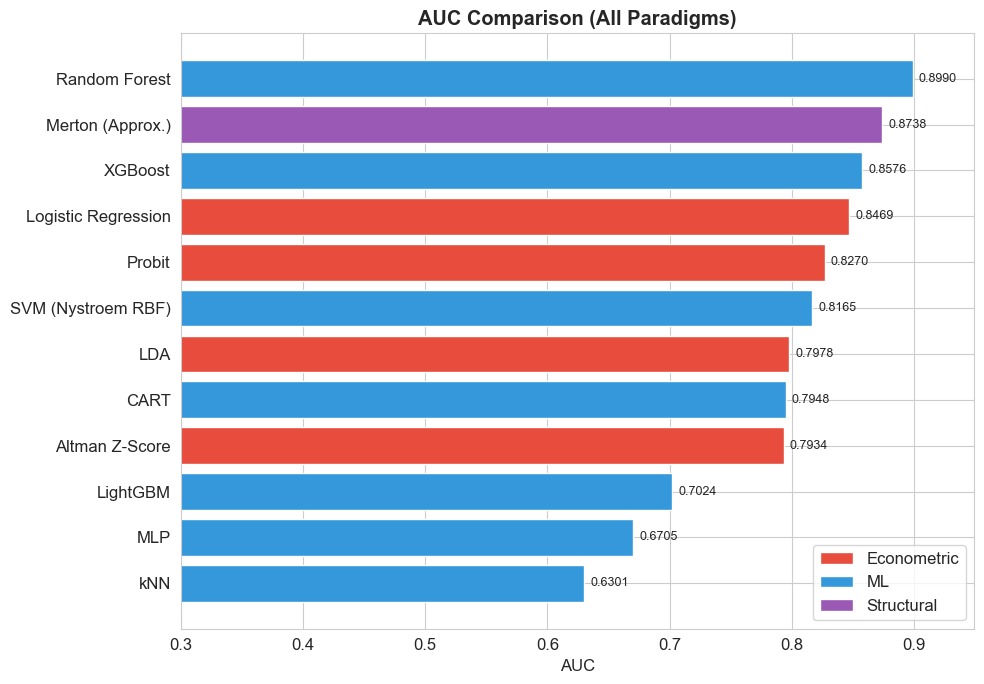

In [32]:
fig,ax=plt.subplots(figsize=(10,7))
pc={'Econometric':'#e74c3c','ML':'#3498db','Structural':'#9b59b6'}
bc=[pc.get(results[m]['paradigm'],'#95a5a6') for m in comp['Model']]
bars=ax.barh(comp['Model'],comp['auc'],color=bc); ax.set_xlabel('AUC')
ax.set_title('AUC Comparison (All Paradigms)',fontweight='bold'); ax.set_xlim([0.3,max(comp['auc'])+0.05]); ax.invert_yaxis()
for b,v in zip(bars,comp['auc']): ax.text(v+0.005,b.get_y()+b.get_height()/2,f'{v:.4f}',va='center',fontsize=9)
# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c',label='Econometric'), Patch(facecolor='#3498db',label='ML'), Patch(facecolor='#9b59b6',label='Structural')]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout(); plt.show()

### Discussion

This is the **only dataset** in the study where **all 4 paradigms** are applicable:

1. **Paradigm 1 (Econometric)**: Logistic Regression/Probit/LDA serve as baselines.
   **Altman Z-Score** is FULLY computed with actual market capitalization (X8),
   making it the most faithful implementation across all datasets.

2. **Paradigm 2 (ML)**: Gradient boosting dominates, but the OOT split provides a
   more realistic (and typically lower) performance estimate than random splitting.

3. **Paradigm 3 (Structural)**: The **Merton model** is partially implemented using
   market capitalization (X8) as equity value and year-to-year changes as volatility proxy.
   True implementation would require daily stock price data.

4. **Paradigm 4 (Dynamic)**:
   - **Markov Chains**: Fully implemented — transition matrix shows annual P(Alive→Failed).
     Multi-step transitions enable n-year default probability forecasting.
   - **Cox PH**: Fully implemented — survival analysis of company lifetimes with
     financial covariates. Concordance index provides model discrimination measure.

#### OOT Validation Insight
The Out-of-Time split is critical for real-world credit scoring validation.
Models trained on 1999–2014 data and tested on 2015–2018 simulate actual deployment conditions.

---
## End of Analysis